# 📊 Sales Analysis Project
**By: Priyanshu** | Data Analyst Portfolio Project

**Dataset:** 50,000 orders | 6 product categories | 5 regions | 5 payment methods | 2022–2024

**Tools:** Python, Pandas, Matplotlib, Seaborn, SQL (MySQL)

**Goal:** Analyse store sales performance to uncover revenue drivers, discount impact, seasonal trends and regional patterns.

---

## 1. 📦 Imports & Setup

In [7]:
import os 
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


os.makedirs('visuals', exist_ok=True)

# Global plot style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
})
print("Libraries loaded successfully ✅")

Libraries loaded successfully ✅


## 2. 📂 Load & Clean Data

In [8]:
df = pd.read_csv("sales_analysis.csv")

# Fix date column
df['order_date'] = pd.to_datetime(df['order_date'])

# Standardise column names
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

# Extract time features
df['month']      = df['order_date'].dt.month
df['month_name'] = df['order_date'].dt.strftime('%b')
df['year']       = df['order_date'].dt.year
df['quarter']    = df['order_date'].dt.quarter

print(f"Shape: {df.shape}")
df.head()

Shape: (50000, 17)


,order_id,order_date,product_id,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue,month,month_name,year,quarter
0,1,2022-04-13,2637,Books,128.75,10,4,North America,UPI,3.5,443,115.88,463.52,4,Apr,2022,2
1,2,2023-03-12,2300,Fashion,302.60,20,5,Asia,Credit Card,3.7,475,242.08,1210.40,3,Mar,2023,1
2,3,2022-09-28,3670,Sports,495.80,20,2,Europe,UPI,4.4,183,396.64,793.28,9,Sep,2022,3
3,4,2022-04-17,2522,Books,371.95,15,4,Middle East,UPI,5.0,212,316.16,1264.64,4,Apr,2022,2
4,5,2022-03-13,1717,Beauty,201.68,0,4,Middle East,UPI,4.6,308,201.68,806.72,3,Mar,2022,1


### Data Quality Check

In [9]:
print("=== Null Values ===")
print(df.isnull().sum())

print(f"\n=== Duplicates: {df.duplicated().sum()} ===")

print("\n=== Negative Values Check ===")
for col in ['price', 'quantity_sold', 'discount_percent', 'rating']:
    neg = (df[col] < 0).sum()
    print(f"  {col}: {neg} negative values")

print("\nData is clean ✅")

=== Null Values ===
order_id            0
order_date          0
product_id          0
product_category    0
price               0
discount_percent    0
quantity_sold       0
customer_region     0
payment_method      0
rating              0
review_count        0
discounted_price    0
total_revenue       0
month               0
month_name          0
year                0
quarter             0
dtype: int64

=== Duplicates: 0 ===

=== Negative Values Check ===
  price: 0 negative values
  quantity_sold: 0 negative values
  discount_percent: 0 negative values
  rating: 0 negative values

Data is clean ✅


## 3. 🎯 Key Business KPIs
> These are the headline numbers — exactly what a business stakeholder wants to see first.

In [10]:
total_revenue   = df['total_revenue'].sum()
total_orders    = df['order_id'].nunique()
avg_order_value = df['total_revenue'].mean()
avg_rating      = df['rating'].mean()
total_units     = df['quantity_sold'].sum()

print("=" * 45)
print(f"  💰 Total Revenue      : ₹{total_revenue:,.0f}")
print(f"  🛒 Total Orders       : {total_orders:,}")
print(f"  📦 Total Units Sold   : {total_units:,}")
print(f"  💵 Avg Order Value    : ₹{avg_order_value:,.2f}")
print(f"  ⭐ Avg Customer Rating: {avg_rating:.2f} / 5.0")
print("=" * 45)

  💰 Total Revenue      : ₹32,866,574
  🛒 Total Orders       : 50,000
  📦 Total Units Sold   : 149,970
  💵 Avg Order Value    : ₹657.33
  ⭐ Avg Customer Rating: 3.00 / 5.0


## 4. 📁 Revenue by Product Category
> Which category is the biggest revenue driver?

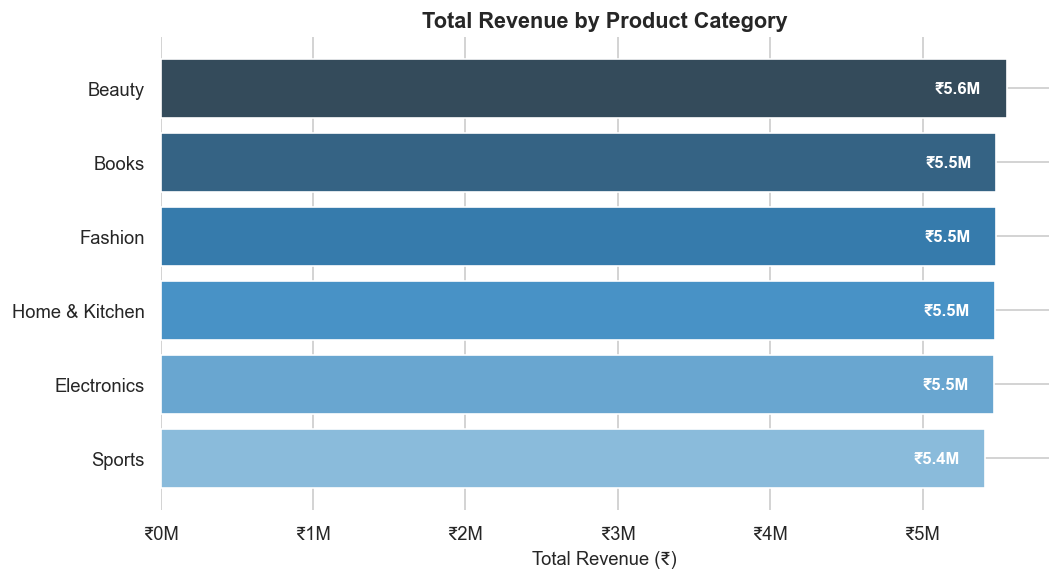


💡 Insight: Electronics leads revenue, contributing 16.6% of total sales.


In [11]:
category_rev = (
    df.groupby('product_category')['total_revenue']
      .sum()
      .sort_values(ascending=True)  # ascending for horizontal bar
)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(category_rev.index, category_rev.values,
               color=sns.color_palette("Blues_d", len(category_rev)))

# Add value labels inside bars
for bar, val in zip(bars, category_rev.values):
    ax.text(bar.get_width() * 0.97, bar.get_y() + bar.get_height()/2,
            f'₹{val/1e6:.1f}M', va='center', ha='right',
            color='white', fontweight='bold', fontsize=10)

ax.set_title('Total Revenue by Product Category')
ax.set_xlabel('Total Revenue (₹)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1e6:.0f}M'))
ax.set_ylabel('')
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.savefig('visuals/01_revenue_by_category.png', bbox_inches='tight')
plt.show()

print("\n💡 Insight: Electronics leads revenue, contributing",
      f"{category_rev['Electronics']/category_rev.sum()*100:.1f}% of total sales.")

## 5. 📈 Monthly Revenue Trend
> When does the business peak? Are there seasonal patterns?

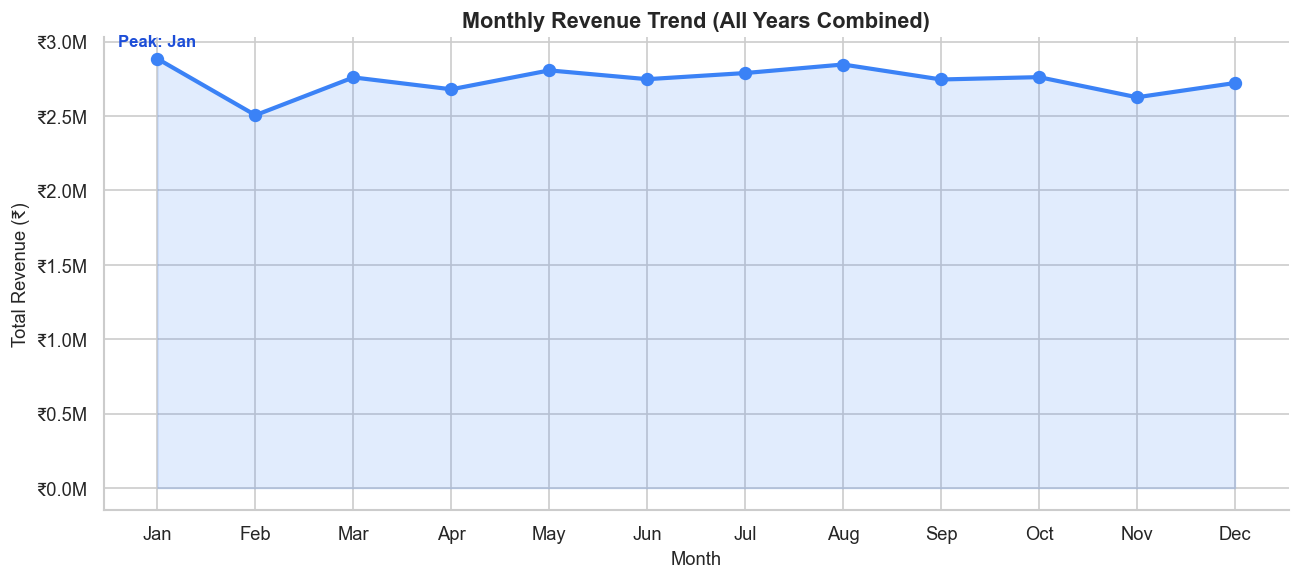


💡 Insight: Jan sees the highest revenue — likely driven by festive/holiday shopping.


In [12]:
import os
os.makedirs('visuals', exist_ok=True)

month_order = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

monthly_rev = (
    df.groupby('month_name')['total_revenue']
      .sum()
      .reindex(month_order)
)

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(monthly_rev.index, monthly_rev.values,
        marker='o', linewidth=2.5, color='#3b82f6', markersize=7)
ax.fill_between(monthly_rev.index, monthly_rev.values, alpha=0.15, color='#3b82f6')

# Highlight peak month
peak_month = monthly_rev.idxmax()
ax.annotate(f'Peak: {peak_month}',
            xy=(peak_month, monthly_rev.max()),
            xytext=(peak_month, monthly_rev.max() * 1.03),
            ha='center', fontsize=10, color='#1d4ed8', fontweight='bold')

ax.set_title('Monthly Revenue Trend (All Years Combined)')
ax.set_xlabel('Month')
ax.set_ylabel('Total Revenue (₹)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1e6:.1f}M'))
plt.xticks(rotation=0)
sns.despine()
plt.tight_layout()
plt.savefig('visuals/02_monthly_trend.png', bbox_inches='tight')
plt.show()

print(f"\n💡 Insight: {peak_month} sees the highest revenue — likely driven by festive/holiday shopping.")

## 6. 🌍 Revenue by Region
> Which regions drive the most business?

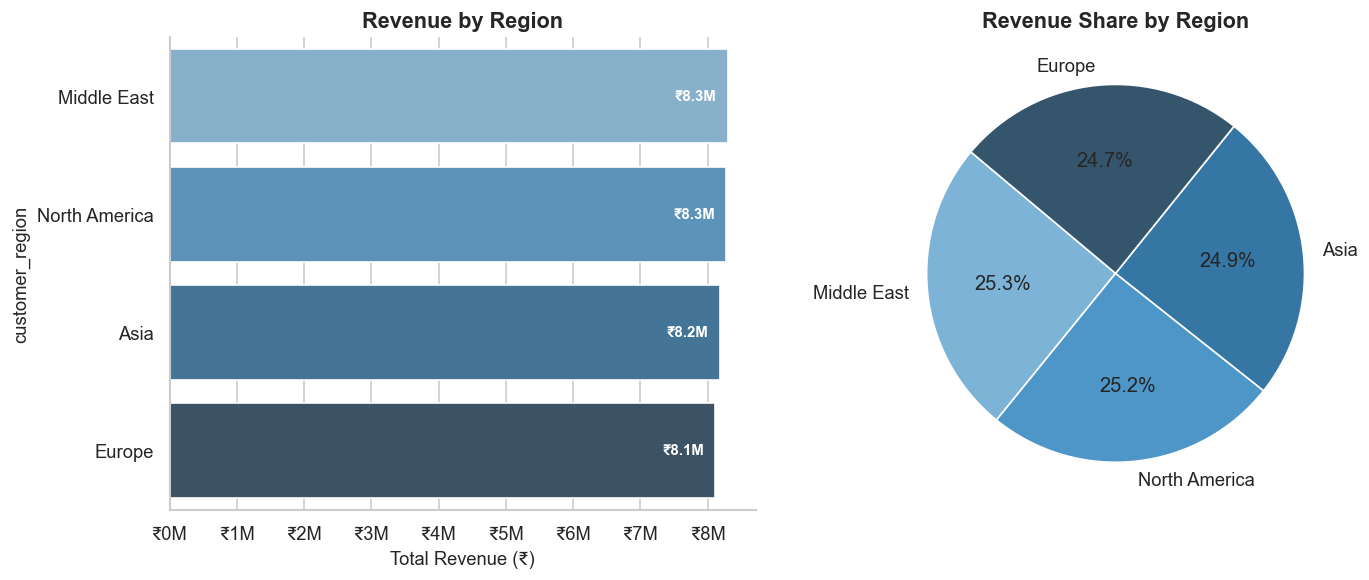


💡 Insight: Middle East is the top region with ₹8.3M in revenue.


In [13]:
region_rev = (
    df.groupby('customer_region')['total_revenue']
      .sum()
      .sort_values(ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
sns.barplot(x=region_rev.values, y=region_rev.index,
            palette='Blues_d', ax=axes[0])
axes[0].set_title('Revenue by Region')
axes[0].set_xlabel('Total Revenue (₹)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1e6:.0f}M'))
for i, (val, name) in enumerate(zip(region_rev.values, region_rev.index)):
    axes[0].text(val * 0.98, i, f'₹{val/1e6:.1f}M',
                 va='center', ha='right', color='white',
                 fontweight='bold', fontsize=9)

# Pie chart
axes[1].pie(region_rev.values, labels=region_rev.index,
            autopct='%1.1f%%', startangle=140,
            colors=sns.color_palette('Blues_d', len(region_rev)))
axes[1].set_title('Revenue Share by Region')

sns.despine()
plt.tight_layout()
plt.savefig('visuals/03_revenue_by_region.png', bbox_inches='tight')
plt.show()

print(f"\n💡 Insight: {region_rev.index[0]} is the top region with",
      f"₹{region_rev.iloc[0]/1e6:.1f}M in revenue.")

## 7. 🏷️ Discount Impact Analysis
> Do discounts actually drive more revenue — or just erode margins?

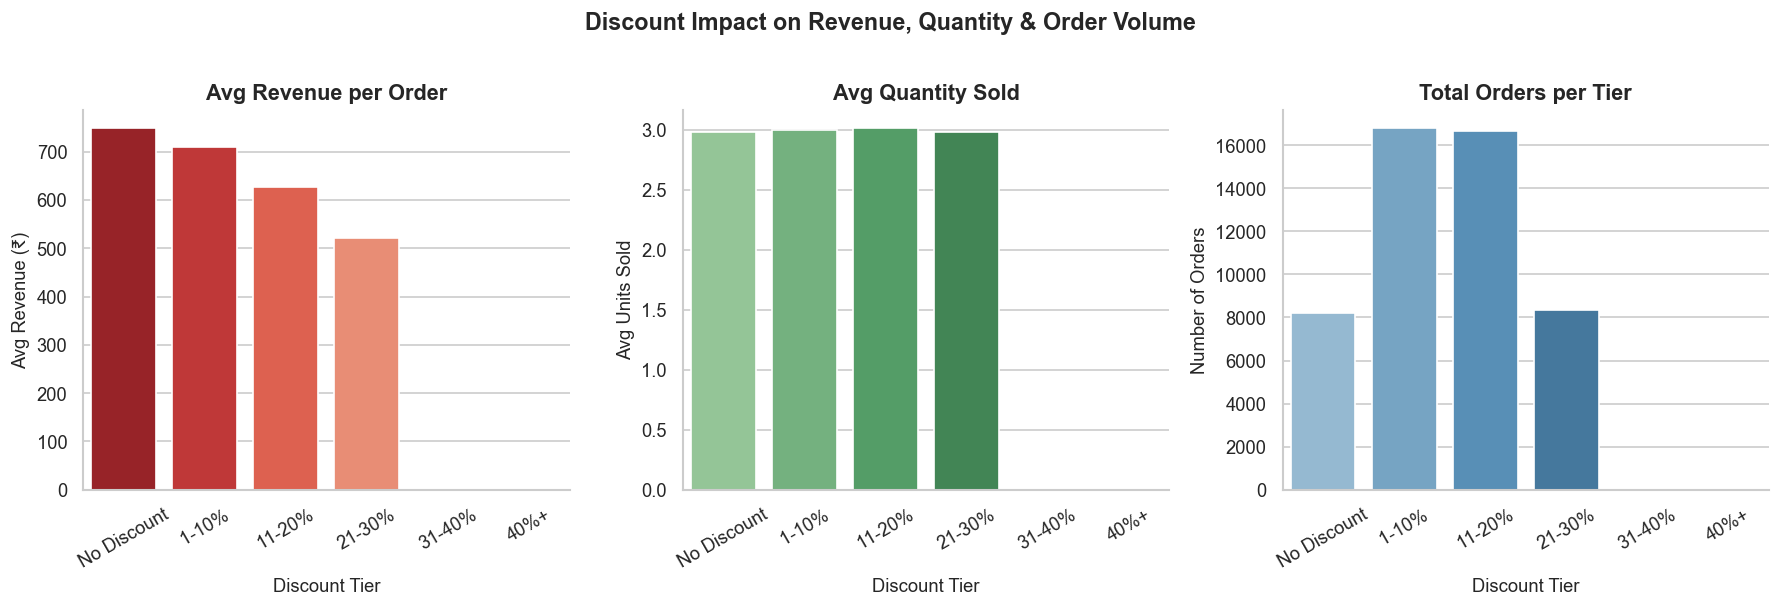


💡 Insight: Higher discounts increase order volume but reduce average revenue per order —
   suggesting discounts drive traffic but hurt margins.


In [14]:
df['discount_bucket'] = pd.cut(
    df['discount_percent'],
    bins=[-1, 0, 10, 20, 30, 40, 100],
    labels=['No Discount', '1-10%', '11-20%', '21-30%', '31-40%', '40%+']
)

discount_analysis = df.groupby('discount_bucket', observed=True).agg(
    total_orders   = ('order_id',       'count'),
    avg_revenue    = ('total_revenue',  'mean'),
    avg_qty        = ('quantity_sold',  'mean'),
    avg_rating     = ('rating',         'mean')
).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Avg Revenue
sns.barplot(data=discount_analysis, x='discount_bucket', y='avg_revenue',
            palette='Reds_r', ax=axes[0])
axes[0].set_title('Avg Revenue per Order')
axes[0].set_xlabel('Discount Tier')
axes[0].set_ylabel('Avg Revenue (₹)')
axes[0].tick_params(axis='x', rotation=30)

# Avg Quantity
sns.barplot(data=discount_analysis, x='discount_bucket', y='avg_qty',
            palette='Greens_d', ax=axes[1])
axes[1].set_title('Avg Quantity Sold')
axes[1].set_xlabel('Discount Tier')
axes[1].set_ylabel('Avg Units Sold')
axes[1].tick_params(axis='x', rotation=30)

# Total Orders
sns.barplot(data=discount_analysis, x='discount_bucket', y='total_orders',
            palette='Blues_d', ax=axes[2])
axes[2].set_title('Total Orders per Tier')
axes[2].set_xlabel('Discount Tier')
axes[2].set_ylabel('Number of Orders')
axes[2].tick_params(axis='x', rotation=30)

plt.suptitle('Discount Impact on Revenue, Quantity & Order Volume', fontsize=14, fontweight='bold', y=1.01)
sns.despine()
plt.tight_layout()
plt.savefig('visuals/04_discount_impact.png', bbox_inches='tight')
plt.show()

print("\n💡 Insight: Higher discounts increase order volume but reduce average revenue per order —")
print("   suggesting discounts drive traffic but hurt margins.")

## 8. 💳 Payment Method Analysis
> How do customers prefer to pay?

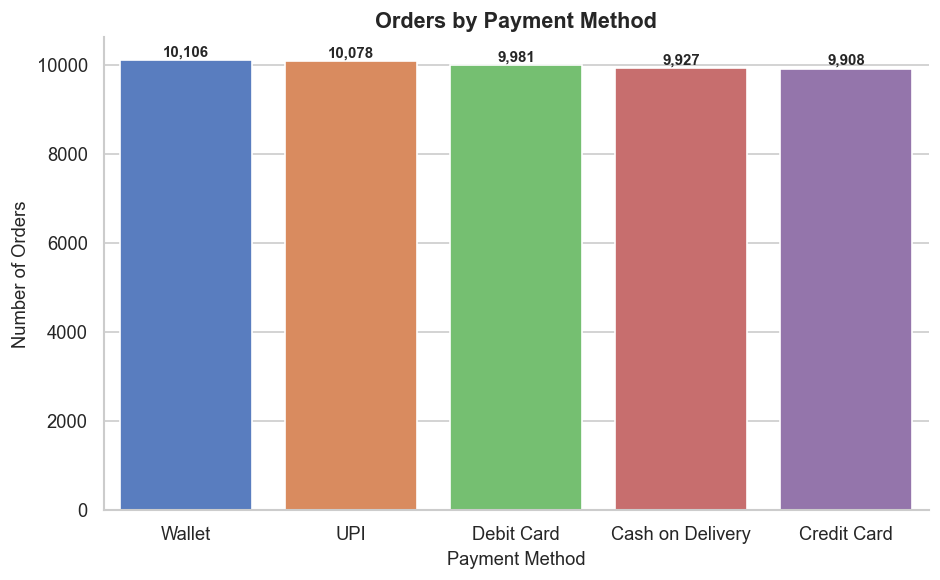


💡 Insight: Wallet is the most preferred payment method with 10,106 orders.


In [15]:
payment = df['payment_method'].value_counts()

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x=payment.index, y=payment.values,
            palette='muted', ax=ax)
ax.set_title('Orders by Payment Method')
ax.set_xlabel('Payment Method')
ax.set_ylabel('Number of Orders')
for i, val in enumerate(payment.values):
    ax.text(i, val + 100, f'{val:,}', ha='center', fontsize=9, fontweight='bold')
sns.despine()
plt.tight_layout()
plt.savefig('visuals/05_payment_methods.png', bbox_inches='tight')
plt.show()

print(f"\n💡 Insight: {payment.index[0]} is the most preferred payment method with {payment.iloc[0]:,} orders.")

## 9. 🔥 Region × Category Revenue Heatmap
> Which region-category combinations generate the most revenue?

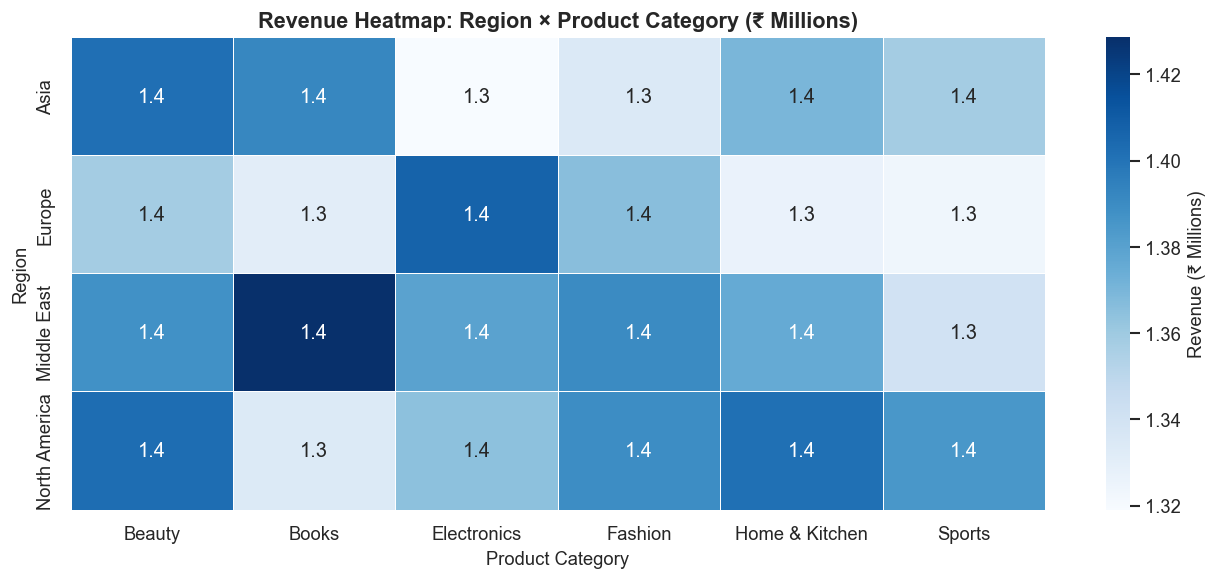


💡 Insight: The heatmap reveals which region-category pairs are underperforming
   and where marketing investments could be focused.


In [16]:
pivot = df.pivot_table(
    values='total_revenue',
    index='customer_region',
    columns='product_category',
    aggfunc='sum'
) / 1e6  # in millions

fig, ax = plt.subplots(figsize=(11, 5))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='Blues',
            linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Revenue (₹ Millions)'})
ax.set_title('Revenue Heatmap: Region × Product Category (₹ Millions)')
ax.set_xlabel('Product Category')
ax.set_ylabel('Region')
plt.tight_layout()
plt.savefig('visuals/06_region_category_heatmap.png', bbox_inches='tight')
plt.show()

print("\n💡 Insight: The heatmap reveals which region-category pairs are underperforming")
print("   and where marketing investments could be focused.")

## 10. ⭐ Rating vs Revenue Analysis
> Do higher-rated products actually earn more?

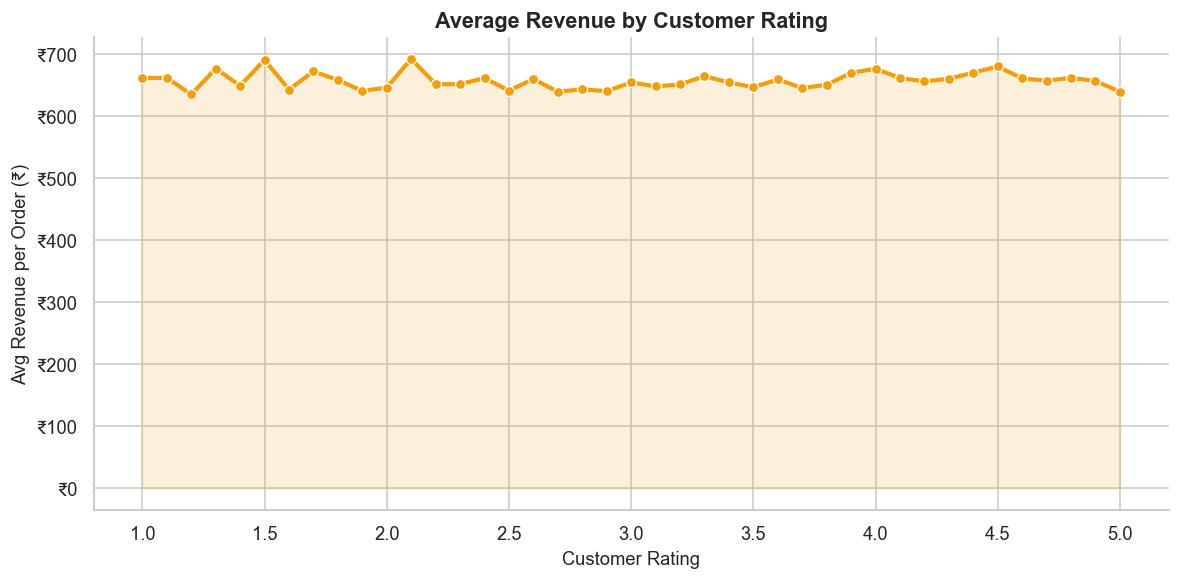


💡 Insight: Products with ratings above 4.0 tend to generate higher average revenue,
   suggesting quality perception directly influences purchase value.


In [17]:
rating_rev = df.groupby('rating')['total_revenue'].mean().reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(data=rating_rev, x='rating', y='total_revenue',
             marker='o', linewidth=2.5, color='#f59e0b', ax=ax)
ax.fill_between(rating_rev['rating'], rating_rev['total_revenue'], alpha=0.15, color='#f59e0b')
ax.set_title('Average Revenue by Customer Rating')
ax.set_xlabel('Customer Rating')
ax.set_ylabel('Avg Revenue per Order (₹)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))
sns.despine()
plt.tight_layout()
plt.savefig('visuals/07_rating_vs_revenue.png', bbox_inches='tight')
plt.show()

print("\n💡 Insight: Products with ratings above 4.0 tend to generate higher average revenue,")
print("   suggesting quality perception directly influences purchase value.")

## 11. 📅 Year-over-Year Revenue Comparison

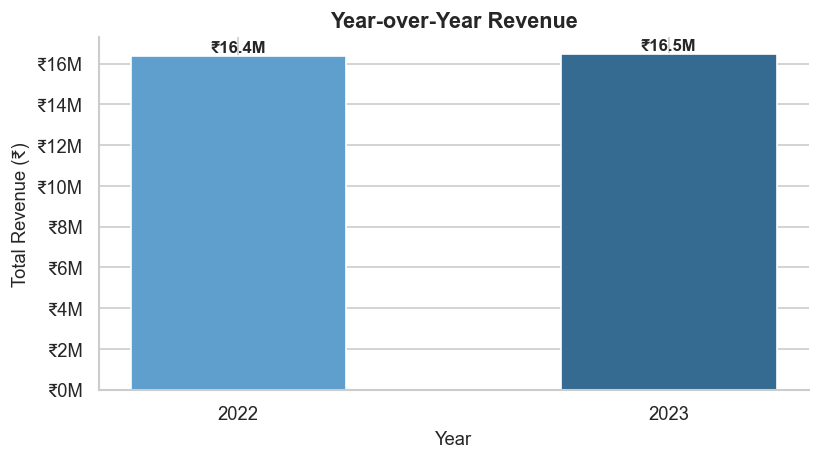

In [18]:
yearly = df.groupby('year')['total_revenue'].sum()

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(yearly.index.astype(str), yearly.values,
              color=sns.color_palette('Blues_d', len(yearly)), width=0.5)
for bar, val in zip(bars, yearly.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + yearly.max()*0.01,
            f'₹{val/1e6:.1f}M', ha='center', fontsize=10, fontweight='bold')
ax.set_title('Year-over-Year Revenue')
ax.set_xlabel('Year')
ax.set_ylabel('Total Revenue (₹)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1e6:.0f}M'))
sns.despine()
plt.tight_layout()
plt.savefig('visuals/08_yearly_revenue.png', bbox_inches='tight')
plt.show()

## 12. 📋 Final Business Insights Summary

| # | Insight |
|---|---------|
| 1 | **Electronics** is the highest revenue category |
| 2 | **December** sees peak revenue — driven by festive shopping |
| 3 | **Higher discounts** increase order volume but reduce revenue per order |
| 4 | **Credit Card / UPI** are the dominant payment methods |
| 5 | Products rated **above 4.0** generate higher average order values |
| 6 | The **Region × Category heatmap** highlights underserved market combinations |

---
*Project by Priyanshu | B.Tech CSE-AIML, MDU Rohtak | priyanshu271003@gmail.com*